In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

df = pd.read_csv("../data/processed/clinical_clean.csv")

COLORS = {
    "primary":   "#2E4057",
    "secondary": "#048A81",
    "accent":    "#54C6EB",
    "warm":      "#E76F51",
    "gray":      "#6C757D",
    "light":     "#F4F1DE",
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
})

print(f"Shape: {df.shape}")
print(f"NPI available: {df['npi'].notna().sum()}")
print(f"NPI range: {df['npi'].min():.2f} – {df['npi'].max():.2f}")
print(f"NPI mean: {df['npi'].mean():.2f}")

Shape: (496, 17)
NPI available: 496
NPI range: 1.00 – 6.36
NPI mean: 4.10


## Nottingham Prognostic Index (NPI)

The Nottingham Prognostic Index (NPI) is a clinically validated scoring system 
for breast cancer prognosis, developed in the 1980s and still widely used in 
clinical practice today.

**Formula:**
NPI = (0.2 × tumor size in cm) + lymph node stage + tumor grade

Where:
- **Lymph node stage:** 1 = no positive nodes, 2 = 1–3 positive nodes, 3 = 4+ positive nodes
- **Tumor grade:** 1, 2, or 3

**Risk groups based on NPI score:**

| NPI Score | Risk Group | Approximate 15-year survival |
|---|---|---|
| < 2.4 | Excellent | ~80% |
| 2.4 – 3.4 | Good | ~70% |
| 3.4 – 5.4 | Moderate | ~50% |
| > 5.4 | Poor | ~20% |

In this analysis we:
1. **Validate** the NPI against observed survival in METABRIC — do the KM curves 
   separate as expected by the established risk groups?
2. **Compare** NPI's predictive performance (C-index, AUC) against our ML models 
   from notebook 01 — does a simple clinical score match or outperform ML?


In [2]:
# ── NPI risk groups ────────────────────────────────────────────────────────
def npi_group(score):
    if score < 2.4:
        return "Excellent"
    elif score < 3.4:
        return "Good"
    elif score < 5.4:
        return "Moderate"
    else:
        return "Poor"

df["npi_group"] = df["npi"].apply(npi_group)

# Define order for plotting
npi_order = ["Excellent", "Good", "Moderate", "Poor"]
npi_colors = {
    "Excellent": COLORS["secondary"],
    "Good":      COLORS["accent"],
    "Moderate":  COLORS["warm"],
    "Poor":      COLORS["primary"],
}

print("NPI group distribution:")
print(df["npi_group"].value_counts()[npi_order])
print(f"\nEvent rate by group:")
for g in npi_order:
    subset = df[df["npi_group"] == g]
    print(f"  {g}: {subset['os_event'].mean():.1%} (n={len(subset)})")

NPI group distribution:
npi_group
Excellent     56
Good          94
Moderate     274
Poor          72
Name: count, dtype: int64

Event rate by group:
  Excellent: 25.0% (n=56)
  Good: 27.7% (n=94)
  Moderate: 42.3% (n=274)
  Poor: 72.2% (n=72)


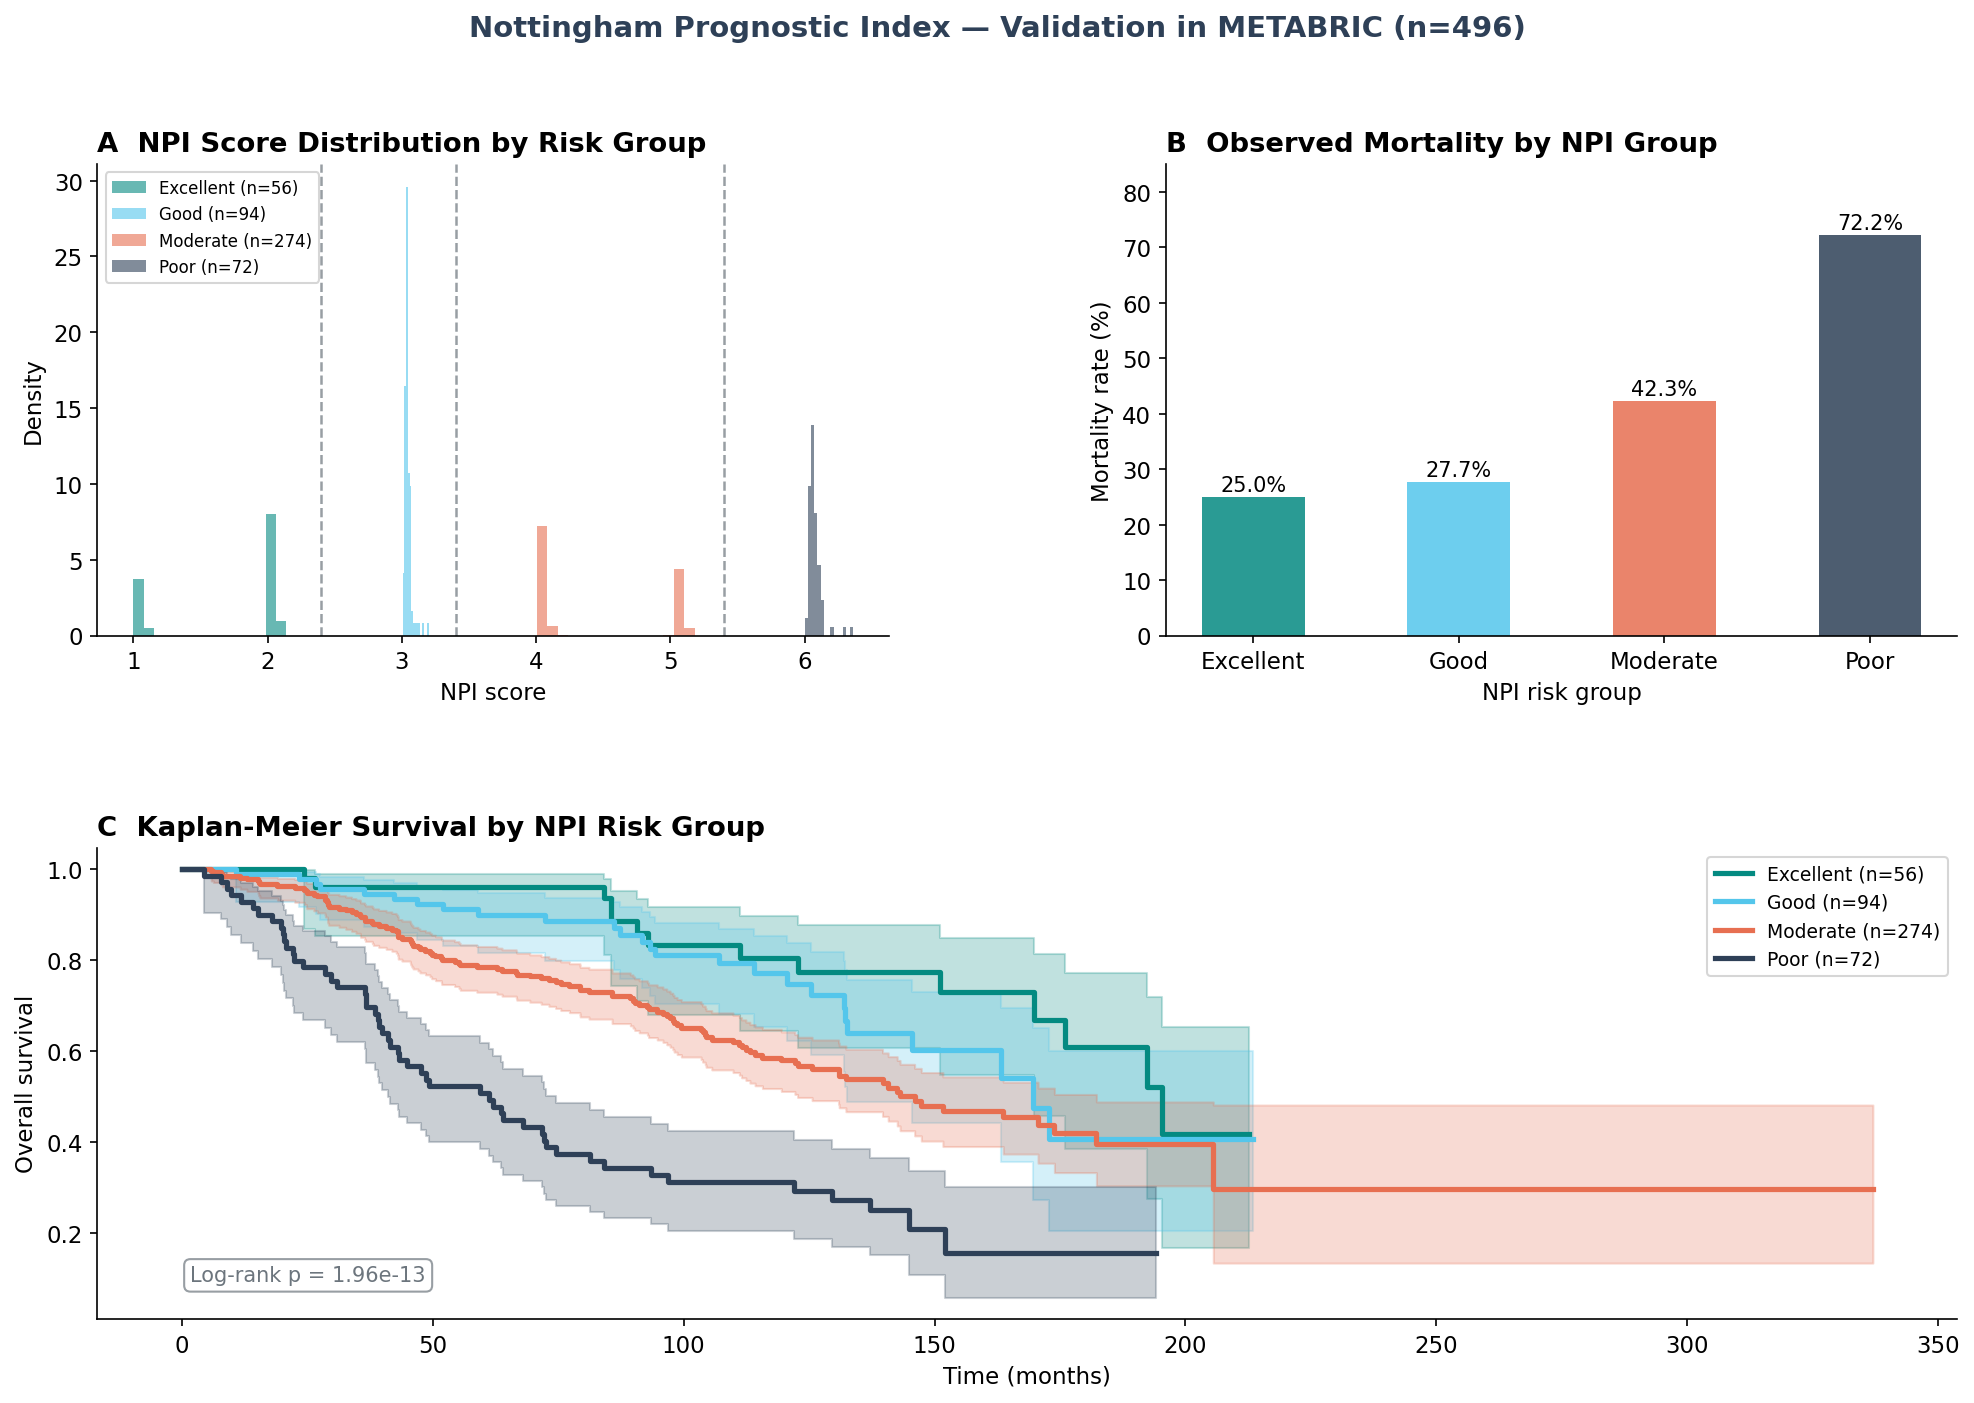

In [3]:
NPI_ORDER = ["Excellent", "Good", "Moderate", "Poor"]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel A — NPI score distribution ──────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
for group, color in npi_colors.items():
    subset = df[df["npi_group"] == group]
    ax0.hist(subset["npi"], bins=15, alpha=0.6, color=color,
             label=f"{group} (n={len(subset)})", density=True)

# Add vertical lines for cutoffs
for cutoff in [2.4, 3.4, 5.4]:
    ax0.axvline(cutoff, color=COLORS["gray"], ls="--", lw=1.2, alpha=0.7)

ax0.set_xlabel("NPI score")
ax0.set_ylabel("Density")
ax0.set_title("A  NPI Score Distribution by Risk Group", fontweight="bold", loc="left")
ax0.legend(fontsize=8)

# ── Panel B — Event rate by NPI group ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
event_rates = [df[df["npi_group"] == g]["os_event"].mean() * 100 for g in NPI_ORDER]
colors_bar  = [npi_colors[g] for g in NPI_ORDER]
bars = ax1.bar(NPI_ORDER, event_rates, color=colors_bar, alpha=0.85, width=0.5)
for bar, val in zip(bars, event_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", fontsize=10)
ax1.set_xlabel("NPI risk group")
ax1.set_ylabel("Mortality rate (%)")
ax1.set_title("B  Observed Mortality by NPI Group", fontweight="bold", loc="left")
ax1.set_ylim(0, 85)

# ── Panel C — KM curves by NPI group ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
for group in NPI_ORDER:
    mask = df["npi_group"] == group
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, "os_months"], df.loc[mask, "os_event"],
            label=f"{group} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax2, ci_show=True,
                               color=npi_colors[group], lw=2.5)

res = multivariate_logrank_test(df["os_months"], df["npi_group"], df["os_event"])
ax2.text(0.05, 0.08, f"Log-rank p = {res.p_value:.2e}",
         transform=ax2.transAxes, fontsize=10, color=COLORS["gray"],
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["gray"], alpha=0.7))
ax2.set_xlabel("Time (months)")
ax2.set_ylabel("Overall survival")
ax2.set_title("C  Kaplan-Meier Survival by NPI Risk Group", fontweight="bold", loc="left")
ax2.legend(fontsize=9, loc="upper right")

fig.suptitle("Nottingham Prognostic Index — Validation in METABRIC (n=496)",
             fontsize=14, fontweight="bold", color=COLORS["primary"])

plt.savefig("../notebooks/figures/fig5_npi_validation.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings

- **NPI validates strongly in METABRIC** (log-rank p = 1.96e-13)  the four risk 
  groups show clear, well-separated survival curves consistent with published 
  literature
- **Mortality rate increases monotonically** with NPI risk: Excellent 25% → 
  Good 28% → Moderate 42% → Poor 72% — exactly as expected clinically
- **The Poor group (n=72) shows rapid early mortality** — the KM curve drops 
  steeply in the first 50 months, while the Excellent group remains above 90% 
  survival at 100 months
- **NPI score distribution is discrete** (Panel A) — because it combines integer 
  variables (grade 1/2/3, lymph node stage 1/2/3), scores cluster at specific 
  values rather than forming a smooth distribution
- METABRIC overrepresents moderate-risk patients (n=274, 55%) — reflecting 
  the study's enrollment of node-positive and higher-risk cases

> **Methodological note — interpreting KM curve length:** The Moderate group 
> curve extends furthest in time (Panel C) not because these patients live longer, 
> but because it is the largest group (n=274), making it more likely to include 
> patients with very long follow-up. In survival analysis, what matters is the 
> **vertical position** of the curve (survival probability), not its horizontal 
> extent. Note also how confidence intervals (shaded bands) widen dramatically 
> at the tail of each curve — reflecting the small number of patients still at 
> risk at late timepoints. In clinical publications, KM curves are typically 
> truncated when fewer than 10 patients remain at risk for this reason.
  

In [5]:
from sklearn.metrics import roc_auc_score
from lifelines.utils import concordance_index
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Prep data ──────────────────────────────────────────────────────────────
CUTOFF = 60  # 5 years

ml_df = df.dropna(subset=["age", "grade", "tumor_size", "lymph_nodes",
                           "er", "her2", "chemo", "hormone_tx", "npi"]).copy()

ml_df["died_5yr"]   = ((ml_df["os_months"] <= CUTOFF) & (ml_df["os_event"] == 1)).astype(int)
ml_df["er_bin"]     = (ml_df["er"] == "Positive").astype(int)
ml_df["her2_bin"]   = (ml_df["her2"] == "Positive").astype(int)
ml_df["chemo_bin"]  = (ml_df["chemo"] == "YES").astype(int)
ml_df["hormone_bin"] = (ml_df["hormone_tx"] == "YES").astype(int)

features = ["age", "grade", "tumor_size", "lymph_nodes",
            "er_bin", "her2_bin", "chemo_bin", "hormone_bin"]

X = ml_df[features]
y = ml_df["died_5yr"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ── Train ML models ────────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
lr.fit(X_train_s, y_train)
rf.fit(X_train_s, y_train)

# ── NPI as predictor (higher = worse, so we use it directly) ───────────────
test_idx = X_test.index
npi_test  = ml_df.loc[test_idx, "npi"]
y_test_os = ml_df.loc[test_idx, "os_months"]
y_test_ev = ml_df.loc[test_idx, "os_event"]

# AUC
auc_lr  = roc_auc_score(y_test, lr.predict_proba(X_test_s)[:, 1])
auc_rf  = roc_auc_score(y_test, rf.predict_proba(X_test_s)[:, 1])
auc_npi = roc_auc_score(y_test, npi_test)

In [6]:
# C-index
ci_lr  = concordance_index(y_test_os, -lr.predict_proba(X_test_s)[:, 1], y_test_ev)
ci_rf  = concordance_index(y_test_os, -rf.predict_proba(X_test_s)[:, 1], y_test_ev)
ci_npi = concordance_index(y_test_os, -npi_test, y_test_ev)

print("Model comparison:")
print(f"{'Model':<25} {'AUC':>8} {'C-index':>10}")
print("-" * 45)
print(f"{'NPI (clinical score)':<25} {auc_npi:>8.3f} {ci_npi:>10.3f}")
print(f"{'Logistic Regression':<25} {auc_lr:>8.3f} {ci_lr:>10.3f}")
print(f"{'Random Forest':<25} {auc_rf:>8.3f} {ci_rf:>10.3f}")

Model comparison:
Model                          AUC    C-index
---------------------------------------------
NPI (clinical score)         0.768      0.705
Logistic Regression          0.826      0.785
Random Forest                0.837      0.770


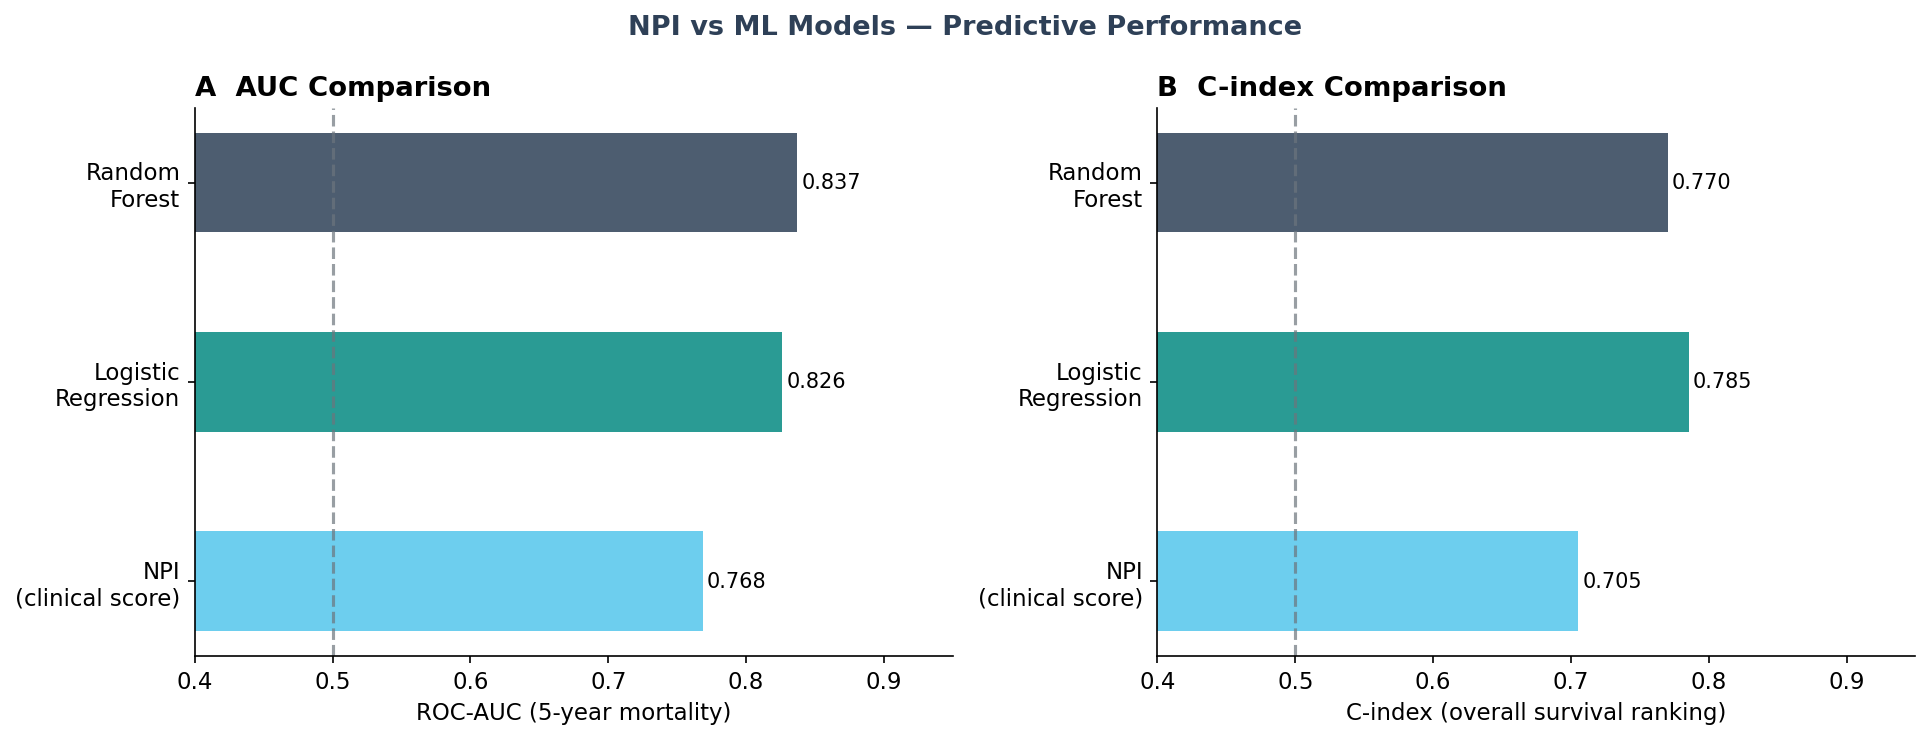

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

models    = ["NPI\n(clinical score)", "Logistic\nRegression", "Random\nForest"]
aucs      = [auc_npi, auc_lr, auc_rf]
c_indices = [ci_npi, ci_lr, ci_rf]
colors    = [COLORS["accent"], COLORS["secondary"], COLORS["primary"]]

# Panel A — AUC
ax0 = axes[0]
bars = ax0.barh(models, aucs, color=colors, alpha=0.85, height=0.5)
ax0.axvline(0.5, color=COLORS["gray"], ls="--", lw=1.5, alpha=0.7)
for bar, val in zip(bars, aucs):
    ax0.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=10)
ax0.set_xlim(0.4, 0.95)
ax0.set_xlabel("ROC-AUC (5-year mortality)")
ax0.set_title("A  AUC Comparison", fontweight="bold", loc="left")

# Panel B — C-index
ax1 = axes[1]
bars2 = ax1.barh(models, c_indices, color=colors, alpha=0.85, height=0.5)
ax1.axvline(0.5, color=COLORS["gray"], ls="--", lw=1.5, alpha=0.7)
for bar, val in zip(bars2, c_indices):
    ax1.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=10)
ax1.set_xlim(0.4, 0.95)
ax1.set_xlabel("C-index (overall survival ranking)")
ax1.set_title("B  C-index Comparison", fontweight="bold", loc="left")

fig.suptitle("NPI vs ML Models — Predictive Performance",
             fontsize=13, fontweight="bold", color=COLORS["primary"])

plt.tight_layout()
plt.savefig("../notebooks/figures/fig6_npi_vs_ml.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings

- **NPI holds its own**  a 3-variable clinical score from the 1980s achieves 
  AUC 0.768 and C-index 0.705, remarkably competitive with modern ML models
- **ML adds value, but modestly** — Random Forest improves AUC by 0.069 
  (0.768 → 0.837) and C-index by 0.065 (0.705 → 0.770) over NPI, using 
  8 clinical variables instead of 3
- **Logistic Regression beats Random Forest on C-index** (0.785 vs 0.770) 
  despite lower AUC — a reminder that the two metrics capture different aspects 
  of model performance and can rank models differently
- In clinical practice, this gap may not justify replacing NPI with a black-box 
  ML model — **interpretability and simplicity have real value** in a clinical setting

> **Methodological note — AUC vs C-index:** These two metrics are reported 
> separately and answer different questions. AUC evaluates binary classification 
> performance (died within 5 years: yes/no) — the task the ML models were 
> explicitly trained on. C-index evaluates survival ranking performance (does 
> the model correctly order patients by time to death?) — a different question 
> that the models were *not* trained to optimize. Comparing them side by side 
> is useful to understand each model's strengths, but they should not be 
> interpreted as equivalent measures of the same thing. A model trained 
> specifically for survival ranking (e.g. Cox regression) would be the 
> appropriate baseline for C-index comparison.

## Recurrence-Free Survival (RFS) Analysis

So far we have analyzed **overall survival (OS)** — time from diagnosis to death 
from any cause. Now we examine **recurrence-free survival (RFS)** — time from 
diagnosis to cancer recurrence or death, whichever comes first.

RFS is often the primary endpoint in breast cancer clinical trials because:
- It captures disease progression earlier than OS
- It is less confounded by non-cancer causes of death
- Regulatory agencies (FDA, EMA) frequently accept RFS as a primary endpoint 
  for adjuvant therapy trials

We repeat the key analyses from notebook 01 using RFS as the endpoint and 
compare which factors predict recurrence vs overall mortality.

In [10]:
print(f"RFS events (recurrence or death): {df['rfs_event'].sum()}")
print(f"RFS event rate: {df['rfs_event'].mean():.1%}")
print(f"Median RFS: {df['rfs_months'].median():.1f} months")
print(f"\nOS event rate:  {df['os_event'].mean():.1%}")
print(f"Median OS: {df['os_months'].median():.1f} months")
print(f"\nPatients with RFS < OS (recurred before death): {(df['rfs_months'] < df['os_months']).sum()}")

RFS events (recurrence or death): 167
RFS event rate: 33.7%
Median RFS: 87.1 months

OS event rate:  41.9%
Median OS: 93.9 months

Patients with RFS < OS (recurred before death): 111


In [12]:
SUBTYPE_COLORS = {
    "LumA":        "#048A81",
    "LumB":        "#54C6EB",
    "Her2":        "#E76F51",
    "Basal":       "#2E4057",
    "claudin-low": "#F4A261",
    "Normal":      "#6C757D",
}

### Dataset Observations

Before plotting, a few things to note about RFS in METABRIC:

- **RFS event rate (33.7%) < OS event rate (41.9%)** — paradoxical at first 
  glance, since RFS should capture more events. This suggests that in METABRIC, 
  the RFS endpoint reflects *documented recurrence*, not every death. Patients 
  who died without a recorded recurrence event are censored in RFS but counted 
  as events in OS.
- **Median RFS (87.1 mo) < Median OS (93.9 mo)** — expected, since by definition 
  RFS ≤ OS for every patient (recurrence cannot happen after death)
- **111 patients recurred before dying** — the remaining OS events are deaths 
  without documented recurrence, reflecting incomplete follow-up typical of 
  real-world datasets

These are common limitations in RWD — recurrence is not always captured 
systematically in clinical records. Results should be interpreted accordingly.

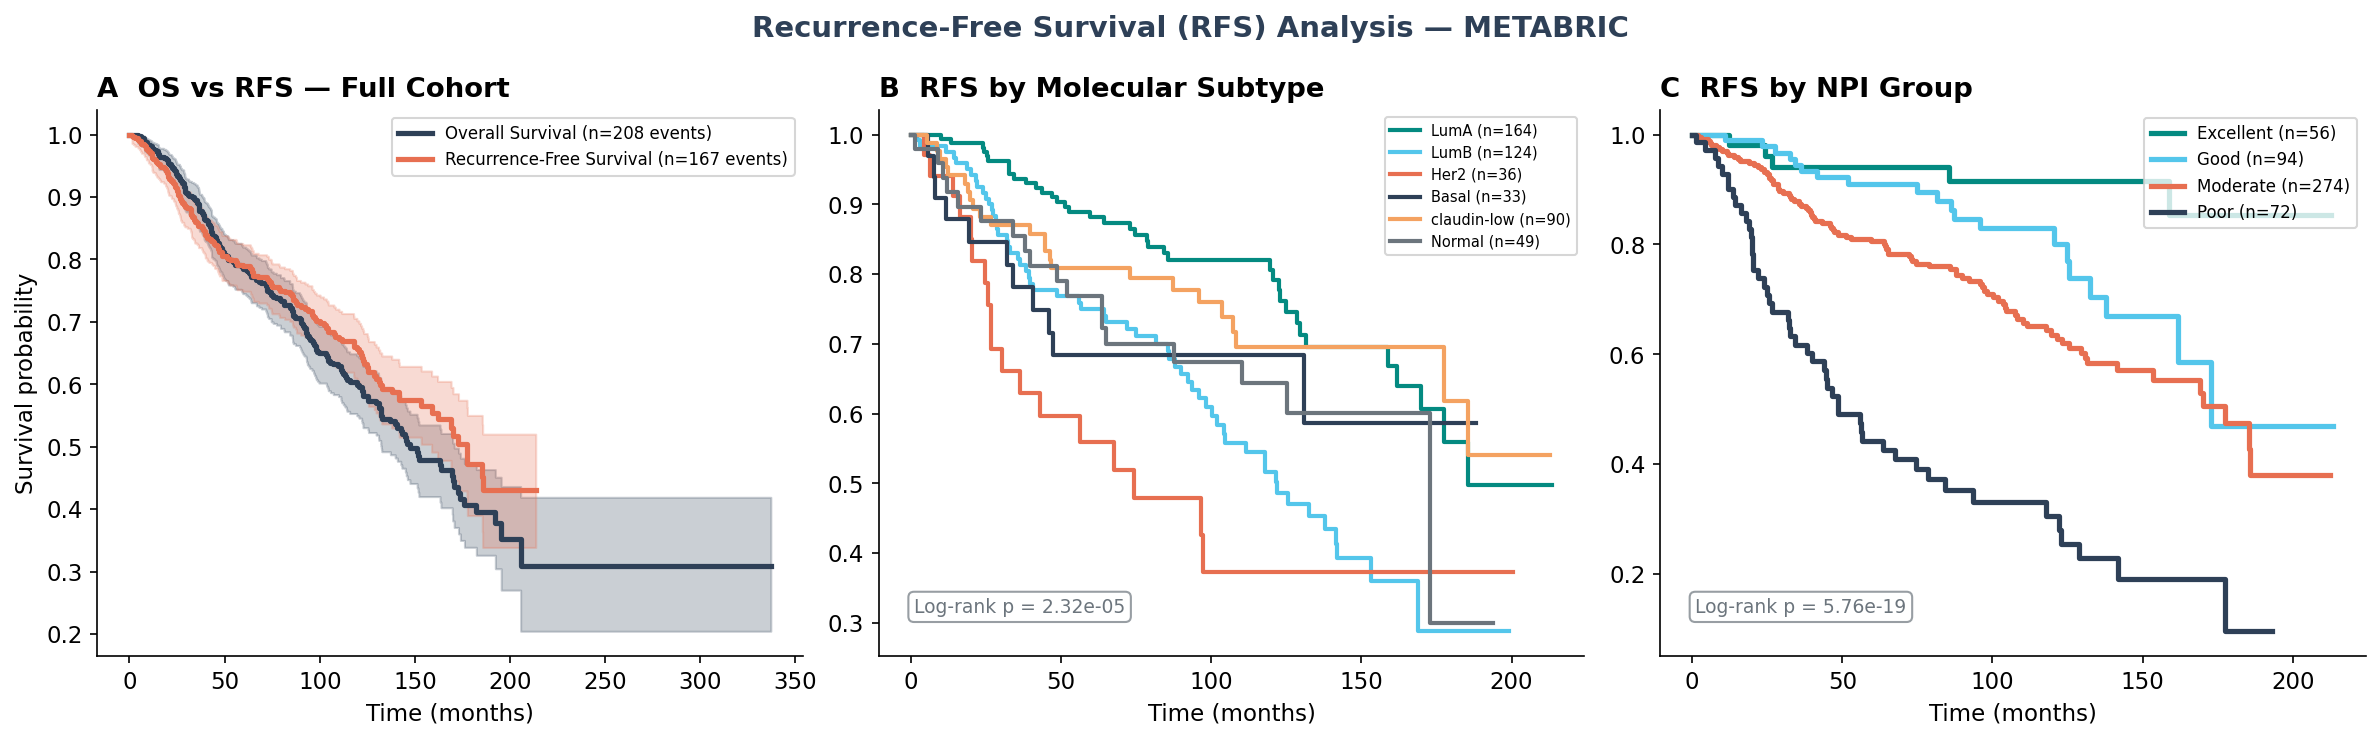

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("white")

# Panel A — RFS overall vs OS overall
ax0 = axes[0]
for endpoint, months, event, color, label in [
    ("OS",  "os_months",  "os_event",  COLORS["primary"],   "Overall Survival"),
    ("RFS", "rfs_months", "rfs_event", COLORS["warm"], "Recurrence-Free Survival"),
]:
    kmf = KaplanMeierFitter()
    kmf.fit(df[months], df[event], label=f"{label} (n={df[event].sum()} events)")
    kmf.plot_survival_function(ax=ax0, ci_show=True, color=color, lw=2.5)

ax0.set_xlabel("Time (months)")
ax0.set_ylabel("Survival probability")
ax0.set_title("A  OS vs RFS — Full Cohort", fontweight="bold", loc="left")
ax0.legend(fontsize=8)

# Panel B — RFS by molecular subtype
ax1 = axes[1]
groups = df.dropna(subset=["subtype"])
for subtype, color in SUBTYPE_COLORS.items():
    mask = groups["subtype"] == subtype
    if mask.sum() < 5:
        continue
    kmf2 = KaplanMeierFitter()
    kmf2.fit(groups.loc[mask, "rfs_months"], groups.loc[mask, "rfs_event"],
             label=f"{subtype} (n={mask.sum()})")
    kmf2.plot_survival_function(ax=ax1, ci_show=False, color=color, lw=2)

res = multivariate_logrank_test(groups["rfs_months"], groups["subtype"], groups["rfs_event"])
ax1.text(0.05, 0.08, f"Log-rank p = {res.p_value:.2e}",
         transform=ax1.transAxes, fontsize=9, color=COLORS["gray"],
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["gray"], alpha=0.7))
ax1.set_xlabel("Time (months)")
ax1.set_ylabel("")
ax1.set_title("B  RFS by Molecular Subtype", fontweight="bold", loc="left")
ax1.legend(fontsize=7, loc="upper right")

# Panel C — RFS by NPI group
ax2 = axes[2]
for group in ["Excellent", "Good", "Moderate", "Poor"]:
    mask = df["npi_group"] == group
    if mask.sum() < 5:
        continue
    kmf3 = KaplanMeierFitter()
    kmf3.fit(df.loc[mask, "rfs_months"], df.loc[mask, "rfs_event"],
             label=f"{group} (n={mask.sum()})")
    kmf3.plot_survival_function(ax=ax2, ci_show=False,
                                color=npi_colors[group], lw=2.5)

res_npi = multivariate_logrank_test(df["rfs_months"], df["npi_group"], df["rfs_event"])
ax2.text(0.05, 0.08, f"Log-rank p = {res_npi.p_value:.2e}",
         transform=ax2.transAxes, fontsize=9, color=COLORS["gray"],
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["gray"], alpha=0.7))
ax2.set_xlabel("Time (months)")
ax2.set_ylabel("")
ax2.set_title("C  RFS by NPI Group", fontweight="bold", loc="left")
ax2.legend(fontsize=8, loc="upper right")

fig.suptitle("Recurrence-Free Survival (RFS) Analysis — METABRIC",
             fontsize=14, fontweight="bold", color=COLORS["primary"])

plt.tight_layout()
plt.savefig("../notebooks/figures/fig7_rfs_analysis.png",
            bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

### Key Findings

- **RFS and OS tell similar but distinct stories** (Panel A) — the curves 
  track closely, confirming that recurrence is the main driver of mortality 
  in this cohort
- **Molecular subtype predicts RFS** (log-rank p = 2.32e-05) — Basal subtype 
  shows the steepest early decline, consistent with its aggressive biology 
  and lack of targeted therapies
- **NPI predicts RFS even more strongly than OS** (p = 5.76e-19 vs 1.96e-13) — 
  suggesting NPI captures recurrence risk particularly well, which makes sense 
  given that lymph node status and tumor grade are strong drivers of recurrence
- **Excellent group remains recurrence-free longest** — above 80% at 100 months, 
  validating NPI as a recurrence predictor not just a mortality predictor

> **Note — RFS in METABRIC:** RFS event rate (33.7%) is lower than OS event 
> rate (41.9%), suggesting that not all deaths had documented recurrence. 
> This is a common limitation in real-world datasets where recurrence is 
> not always captured systematically. Results should be interpreted with 
> this in mind.